# 🎬 Movie Recommendation System using SVD

**Professional ML Project Notebook**

Features:
- Automatic MovieLens dataset download
- Exploratory Data Analysis
- SVD Collaborative Filtering
- Hyperparameter Tuning
- Evaluation (RMSE & MAE)
- Top-N Recommendation Function
- Model Saving/Loading
- Ready for Google Colab


In [1]:
!pip -q install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.1 MB/s eta 0:00:00


In [2]:
import os,zipfile,requests,pickle
import pandas as pd
import matplotlib.pyplot as plt

from surprise import Dataset,Reader,SVD,accuracy
from surprise.model_selection import train_test_split,GridSearchCV


## 1. Download MovieLens Dataset Automatically

In [3]:
URL="https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
ZIP="ml-latest-small.zip"
if not os.path.exists(ZIP):
    r=requests.get(URL)
    open(ZIP,"wb").write(r.content)
if not os.path.exists("ml-latest-small"):
    with zipfile.ZipFile(ZIP) as z:
        z.extractall()
print("Dataset Ready")

Dataset Ready


## 2. Load Dataset

In [4]:
ratings=pd.read_csv("ml-latest-small/ratings.csv")
movies=pd.read_csv("ml-latest-small/movies.csv")
links=pd.read_csv("ml-latest-small/links.csv")
tags=pd.read_csv("ml-latest-small/tags.csv")

print(ratings.shape,movies.shape)
display(ratings.head())
display(movies.head())

(100836, 4) (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 3. Exploratory Data Analysis

              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09


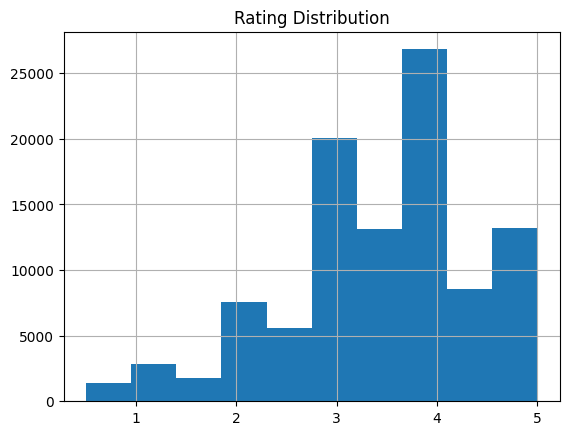

,0
movieId,
356,329
318,317
296,307
593,279
2571,278
260,251
480,238
110,237
589,224


In [5]:
print(ratings.describe())

ratings.rating.hist(bins=10)
plt.title("Rating Distribution")
plt.show()

ratings.groupby("movieId").size().sort_values(ascending=False).head(10)

## 4. Prepare Data

In [6]:
reader=Reader(rating_scale=(0.5,5))
data=Dataset.load_from_df(ratings[["userId","movieId","rating"]],reader)
trainset,testset=train_test_split(data,test_size=0.2,random_state=42)

## 5. Hyperparameter Tuning

In [7]:
param_grid={
'n_factors':[50,100],
'n_epochs':[20,30],
'lr_all':[0.002,0.005],
'reg_all':[0.02,0.1]
}

gs=GridSearchCV(SVD,param_grid,measures=['rmse'],cv=3,n_jobs=-1)
gs.fit(data)

print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

0.8711533393784784
{'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.1}


## 6. Train Final Model

In [8]:
model=SVD(**gs.best_params['rmse'],random_state=42)
model.fit(trainset)

## 7. Evaluate

In [9]:
pred=model.test(testset)
accuracy.rmse(pred)
accuracy.mae(pred)

RMSE: 0.8718
MAE:  0.6700


np.float64(0.6699612539157657)

## 8. Recommendation Function

In [10]:
def recommend_movies(user_id,n=10):
    watched=ratings.loc[ratings.userId==user_id,"movieId"]
    unseen=movies[~movies.movieId.isin(watched)]
    preds=[]
    for mid in unseen.movieId:
        preds.append((mid,model.predict(user_id,mid).est))
    preds.sort(key=lambda x:x[1],reverse=True)
    rec=[]
    for mid,score in preds[:n]:
        title=movies.loc[movies.movieId==mid,"title"].iloc[0]
        genres=movies.loc[movies.movieId==mid,"genres"].iloc[0]
        rec.append([title,genres,round(score,3)])
    return pd.DataFrame(rec,columns=["Movie","Genres","Predicted Rating"])

recommend_movies(1)

,Movie,Genres,Predicted Rating
0,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.000
1,"Streetcar Named Desire, A (1951)",Drama,5.000
2,Paths of Glory (1957),Drama|War,5.000
3,Lawrence of Arabia (1962),Adventure|Drama|War,5.000
4,"Three Billboards Outside Ebbing, Missouri (2017)",Crime|Drama,5.000
5,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,4.992
6,Guess Who's Coming to Dinner (1967),Drama,4.982
7,"Shawshank Redemption, The (1994)",Crime|Drama,4.956
8,On the Waterfront (1954),Crime|Drama,4.951
9,High Noon (1952),Drama|Western,4.944


## 9. Save & Load Model

In [11]:
with open("svd_model.pkl","wb") as f:
    pickle.dump(model,f)

with open("svd_model.pkl","rb") as f:
    loaded_model=pickle.load(f)

print("Model saved and reloaded successfully.")

Model saved and reloaded successfully.


## 10. Interactive Demo

In [12]:
uid=int(input("Enter User ID (1-610): "))
display(recommend_movies(uid))

Enter User ID (1-610): 32


,Movie,Genres,Predicted Rating
0,"Three Billboards Outside Ebbing, Missouri (2017)",Crime|Drama,4.564
1,Paths of Glory (1957),Drama|War,4.529
2,Lawrence of Arabia (1962),Adventure|Drama|War,4.528
3,Rear Window (1954),Mystery|Thriller,4.426
4,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,4.422
5,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,4.416
6,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi,4.409
7,Ran (1985),Drama|War,4.402
8,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,4.394
9,In the Mood For Love (Fa yeung nin wa) (2000),Drama|Romance,4.388


## Future Improvements

- Precision@K / Recall@K
- Content-based filtering using genres
- Hybrid recommender (SVD + Content)
- Streamlit deployment
- Cold-start handling
- Explainable recommendations
